<a href="https://colab.research.google.com/github/joanby/matematicas-ml/blob/master/3_calculus_i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo I: Límites & Derivadas

Este tema, *Cálculo I: Límites y Derivadas*, introduce el campo matemático del cálculo -el estudio de las tasas de cambio- desde cero. Es esencial porque el cálculo de derivadas a través de la diferenciación es la base de la optimización de la mayoría de los algoritmos de aprendizaje automático, incluidos los utilizados en el aprendizaje profundo, como la retropropagación y el descenso de gradiente estocástico.

A través de la exposición mesurada de la teoría junto con ejemplos interactivos, desarrollarás una comprensión práctica de cómo se utiliza el cálculo para calcular límites y diferenciar funciones. También aprenderá a aplicar la diferenciación automática en las populares bibliotecas de aprendizaje automático TensorFlow 2 y PyTorch. El contenido cubierto en esta clase es en sí mismo fundamental para varios otros temas de la serie *Fundamentos del Aprendizaje Automático*, especialmente *Cálculo II* y *Optimización*.

En el transcurso del estudio de este tema, vamos a:

* Desarrollar una comprensión de lo que está pasando bajo el capó de los algoritmos de aprendizaje automático, incluidos los utilizados para el aprendizaje profundo.
* Ser capaz de comprender más íntimamente los detalles de los papeles de aprendizaje automático, así como muchos de los otros temas que subyacen ML, incluyendo el cálculo de derivadas parciales, estadísticas y algoritmos de optimización.
* Calcular las derivadas de funciones, incluyendo el uso de AutoDiff en las populares bibliotecas TensorFlow 2 y PyTorch.

**Tenga en cuenta que este cuaderno Jupyter no está diseñado para funcionar por sí solo. Es el código que acompaña a una clase o a los vídeos de la serie [Fundamentos Matemáticos de Machine Learning](https://github.com/joanby/matematicas-ml) de Frogames Formación, que ofrecen detalles sobre lo siguiente:**

*Segmento 1: Límites*

* Qué es el cálculo
* Breve historia del cálculo
* El método de agotamiento
* Cálculo de límites

*Segmento 2: Cálculo de Derivadas con Diferenciación*
* El Método Delta
* La Ecuación de Diferenciación
* Notación de derivadas
* La regla de la potencia
* Regla de los múltiplos constantes
* Regla de la suma
* Regla del producto
* Regla del cociente
* La regla de la cadena

*Segmento 3: Diferenciación Automática*
* AutoDiff con PyTorch
* AutoDiff con TensorFlow 2
* Aprendizaje automático mediante diferenciación
* Funciones de Coste (o Pérdida)
* El Futuro: Programación Diferenciable

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial. *Nota: de momento solo cubre el Segmento 1 (Límites) — se irá ampliando a medida que avancemos por los Segmentos 2 (Derivadas) y 3 (Diferenciación Automática).*

### Qué es el cálculo (y por qué importa en ciencia de datos)

* **Cálculo diferencial** (este notebook): mide tasas de cambio, mediante **derivadas**. **Cálculo integral**: mide acumulación/áreas (se ve en *Cálculo II*).
* Historia en una línea: método de agotamiento de **Arquímedes** (aproximar con polígonos) → formalizado por **Newton y Leibniz** (s. XVII).
* Por qué importa: entrenar un modelo = optimización (minimizar el error). La derivada (construida sobre límites) es lo que le dice al modelo en qué dirección ajustar sus parámetros — la base del descenso de gradiente y *backpropagation*.

### El concepto de límite

$$ \lim_{x \to a} f(x) = L $$

El valor al que se **acerca** $f(x)$ cuando $x$ se acerca a $a$ — una pregunta sobre *tendencia*, no sobre el valor exacto en ese punto. $f$ ni siquiera necesita estar definida en $x=a$ para que el límite exista.

### Formas indeterminadas y discontinuidades evitables

* Una función puede dar $\frac{0}{0}$ en un punto (no está definida ahí) y aun así tener límite — se dice que tiene una **discontinuidad evitable** («un agujero» en la gráfica).
* Ejemplos: $\lim_{x \to 1} \frac{x^2-1}{x-1}=2$ (se resuelve factorizando) y $\lim_{x \to 0} \frac{\sin x}{x}=1$ (un límite clásico, usado más adelante para derivar el seno).

### Límites en el infinito y límites que no existen

* $\lim_{x \to \infty} f(x)$: qué valor «estabiliza» la función cuando $x$ crece sin límite (asíntota horizontal). Ej: $\lim_{x \to \infty} \frac{25}{x}=0$.
* Si por la izquierda y por la derecha de un punto la función se acerca a valores distintos (o diverge de forma distinta), el límite **no existe** ahí. Ej: $\lim_{x \to 0} \frac{25}{x}$ no existe ($-\infty$ por la izquierda, $+\infty$ por la derecha).
* Truco práctico de `matplotlib`: al representar una función con una asíntota vertical, separa el dominio en dos mitades (antes/después del punto conflictivo) para evitar que dibuje una línea vertical falsa uniendo ambas ramas.

### El método delta: hallar una pendiente exacta

* **Pendiente** = cuánto sube/baja una recta (como una carretera). **Derivada** = la pendiente de una curva, pero en un único punto exacto (como la velocidad instantánea de un coche, no la media del trayecto).
* **Método delta**: para hallar la pendiente exacta en un punto $P$, se coge otro punto $Q$ cercano, se calcula $m=\frac{\Delta y}{\Delta x}$ entre ambos, y se repite acercando $Q$ cada vez más — el valor de $m$ se va estabilizando en un número: esa es la derivada.

### La fórmula de la derivada (y por qué importa en ciencia de datos)

$$ \frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{f(x+\Delta x) - f(x)}{\Delta x} $$

Formalmente: «la pendiente entre dos puntos, cuando la distancia entre ellos se hace cero». En ciencia de datos, si $f(x)$ es el **error** de un modelo y $x$ un **parámetro**, la derivada te dice **en qué dirección y cuánto** ajustar ese parámetro para reducir el error — es el mecanismo exacto detrás del **descenso de gradiente**. Calcularla probando $\Delta x$ pequeños (*diferenciación numérica*, lo que hace este notebook a mano) es la versión manual de lo que las librerías automatizan en el Segmento 3.

### Las reglas de derivación

* Constante ($\frac{d}{dx}[c]=0$), potencia ($\frac{d}{dx}[x^n]=nx^{n-1}$), múltiplo constante, suma, producto y cociente — combinan derivadas conocidas sin repetir el método delta cada vez. En la práctica, `sp.diff()` (o el autograd de PyTorch/TensorFlow) ya las aplica todas por ti.
* **La regla de la cadena** ($\frac{d}{dx}[f(g(x))]=f'(g(x))\cdot g'(x)$) es la más importante para ML: una red neuronal es una composición de funciones, y aplicar la cadena repetidamente capa a capa es exactamente la **retropropagación**. También explica el problema del *vanishing gradient* (multiplicar muchas derivadas pequeñas seguidas). En la práctica se combinan varias reglas a la vez (p. ej. producto + cadena, cuando uno de los factores de un producto es a su vez una composición) — las funciones de coste reales casi nunca son «una sola pieza».

### Diferenciación automática (autodiff)

* **Tres formas de derivar**: numérica (aproximar con $\Delta x$ pequeño), simbólica (SymPy, fórmula exacta) y **automática** (PyTorch/TensorFlow): la librería anota cada operación en un **grafo computacional** y, al pedir la derivada, lo recorre hacia atrás aplicando la regla de la cadena — sin fórmulas escritas a mano.
* Receta de PyTorch: crear tensor → `requires_grad_()` → operar (*forward pass*) → `.backward()` (*backward pass*) → leer `.grad`. En TensorFlow: `tf.Variable` → `tf.GradientTape()` + `t.watch(x)` → `t.gradient(y, x)`.
* Es exactamente el motor de cualquier entrenamiento de ML: forward pass (predicción + error) → backward pass (gradientes de todos los parámetros a la vez) → el optimizador mueve cada parámetro en la dirección que reduce el error. Una regresión lineal $\hat{y}=wx+b$ con error $L=(\hat{y}-y)^2$ es, en esencia, el mismo grafo que $y=x^2$, solo con más operaciones encadenadas.

## Segmento 1: Límites

En este segmento sentamos la base de todo el cálculo: el concepto de **límite**. Antes de poder hablar de derivadas (Segmento 2) o de cómo las calculan automáticamente PyTorch/TensorFlow (Segmento 3), necesitamos entender qué significa que una función se «acerque» a un valor — la idea que hace posible medir, con precisión matemática, la tasa de cambio instantánea de algo. Esa tasa de cambio es, ni más ni menos, lo que permite a un científico de datos **ajustar un modelo a sus datos**: encontrar automáticamente los parámetros que minimizan el error de predicción, en vez de ajustarlos a mano.

### El Cálculo de Infinitesimales

**¿Qué es el cálculo?** Es la rama de las matemáticas que estudia el **cambio continuo**. Se divide en dos mitades que resultan ser inversas la una de la otra:

* **Cálculo diferencial** (el de este notebook): mide *tasas de cambio* — cómo de rápido cambia una cantidad respecto a otra. Su herramienta central es la **derivada**.
* **Cálculo integral**: mide *acumulación* — áreas bajo una curva, sumas continuas. Se verá en *Cálculo II*.

**Breve historia**: la idea germen es el **método de agotamiento**, inventado por **Arquímedes** (~250 a.C.) para calcular el área de figuras curvas (como un círculo) aproximándolas mediante polígonos con cada vez más lados — cuantos más lados, mejor la aproximación, «agotando» el margen de error hasta hacerlo tan pequeño como se quiera. Esa idea de «acercarse tanto como queramos, sin límite» es exactamente la semilla del concepto moderno de **límite**. El cálculo tal y como se enseña hoy fue formalizado casi 2000 años después, de forma independiente, por **Isaac Newton** y **Gottfried Leibniz** a finales del siglo XVII, motivados por describir el movimiento y las tasas de cambio en física.

**¿Por qué importa para la ciencia de datos?** Porque «entrenar un modelo» — ya sea una regresión lineal como la que hicimos a mano en el notebook de álgebra lineal, o una red neuronal — es, en el fondo, un problema de **optimización**: buscar los parámetros que minimizan el error entre lo que predice el modelo y los datos reales. La herramienta que le dice al modelo *en qué dirección* y *cuánto* ajustar cada parámetro para reducir ese error es la **derivada** — y una derivada no es más que un límite. Sin límites no hay derivadas; sin derivadas no hay descenso de gradiente, ni *backpropagation*, ni prácticamente ningún algoritmo de ML capaz de «aprender» de los datos por sí solo. Con la regresión de precios de casas ya viste el resultado final (resolver $w=(X^TX)^{-1}X^Ty$ de un tirón); el cálculo es lo que hace falta cuando ese atajo algebraico no existe, y hay que *buscar* la solución paso a paso.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
x = np.linspace(-10, 10, 10000) # inicio, final, n puntos

Si $y = x^2 + 2x + 2$:

In [4]:
y = x**2 + 2*x + 2

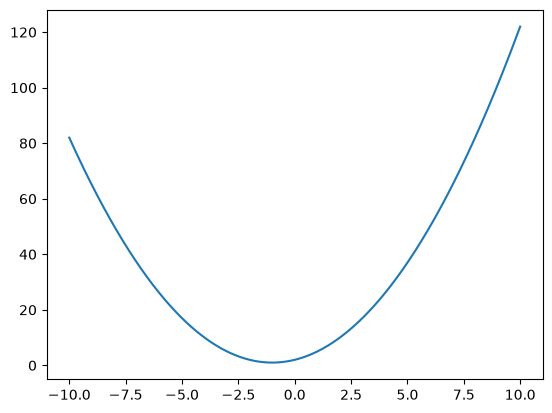

In [5]:
fig, ax = plt.subplots()
_ = ax.plot(x,y)

* No hay líneas rectas en la curva.
* Sin embargo, si nos acercamos _infinitamente_, observamos curvas que se _aproximan_ a rectas.
* Esto nos permite encontrar una pendiente $m$ (tangente) en cualquier punto de la curva, incluso identificar dónde $m = 0$:

Esto es el **método de agotamiento** en acción, aplicado no a un área sino a una curva: cada gráfica de abajo hace *zoom* progresivamente más cerca del punto $(-1, 1)$. Fíjate en que, cuanto más nos acercamos, más recta (plana) parece la curva. Llevado al límite —acercándonos *infinitamente*—, esa «recta» que se ve es la **recta tangente** en ese punto, y su pendiente es exactamente la **derivada** de la función ahí. Es la misma idea geométrica que subyace a todo el cálculo diferencial, antes de que le pongamos números.

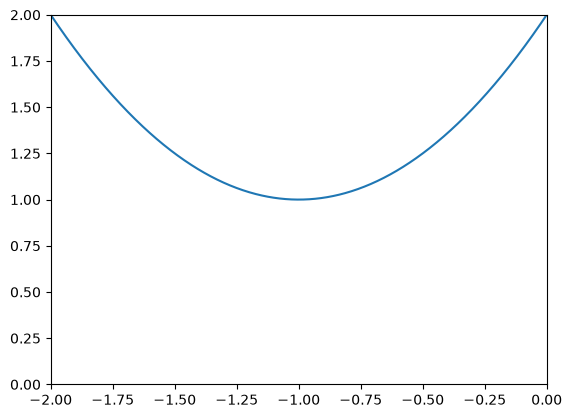

In [6]:
fig, ax = plt.subplots()
ax.set_xlim([-2, -0])
ax.set_ylim([0, 2])
_ = ax.plot(x,y)

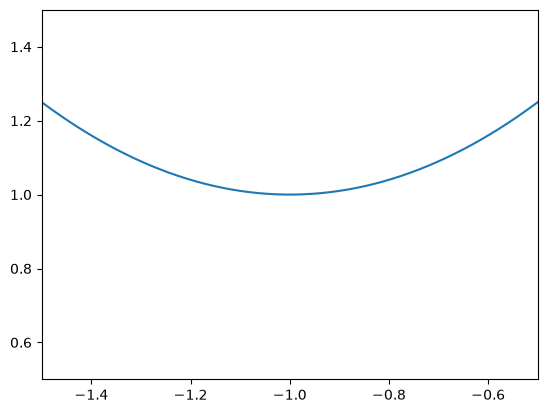

In [7]:
fig, ax = plt.subplots()
ax.set_xlim([-1.5, -0.5])
ax.set_ylim([0.5, 1.5])
_ = ax.plot(x,y)

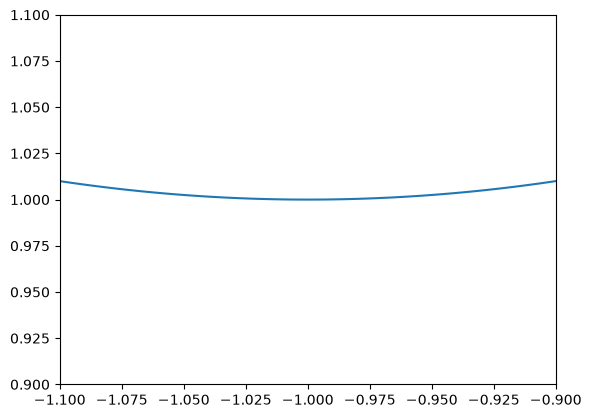

In [8]:
fig, ax = plt.subplots()
ax.set_xlim([-1.1, -0.9])
ax.set_ylim([0.9, 1.1])
_ = ax.plot(x,y)

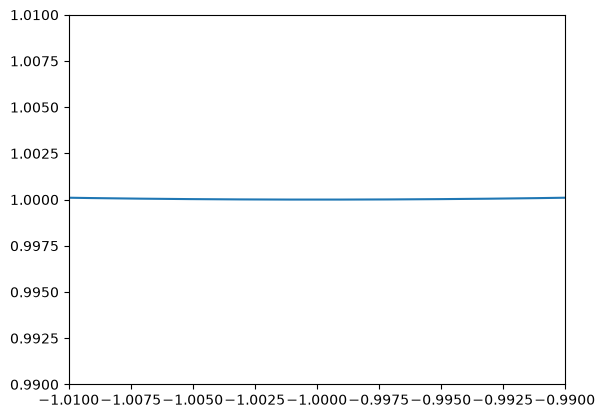

In [9]:
fig, ax = plt.subplots()
ax.set_xlim([-1.01, -0.99])
ax.set_ylim([0.99, 1.01])
_ = ax.plot(x,y)

**Volver a las slides aquí.**

### Límites

Un **límite** describe el valor al que se **acerca** una función $f(x)$ cuando $x$ se acerca a un valor $a$ (por cualquiera de los dos lados), sin que $f$ tenga por qué estar siquiera definida, ni valer eso, exactamente en $x=a$. Se escribe:

$$ \lim_{x \to a} f(x) = L $$

que se lee «el límite de $f(x)$ cuando $x$ tiende a $a$ es $L$». Es una pregunta sobre **tendencia**, no sobre el valor exacto en un punto — una distinción clave que vamos a explotar en los ejemplos siguientes, donde la función ni siquiera está definida en el punto que nos interesa.

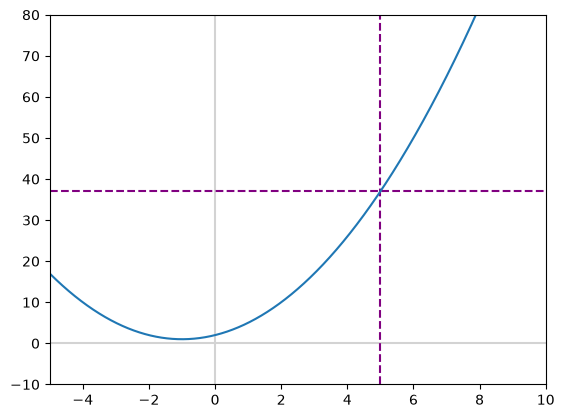

In [10]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-5, 10)
plt.ylim(-10, 80)
plt.axvline(x=5, color='purple', linestyle='--')
plt.axhline(y=37, color='purple', linestyle='--')
_ = ax.plot(x,y)

$$\lim_{x \to 1} \frac{x^2 - 1}{x - 1}$$

In [11]:
def my_fxn(my_x):
    my_y = (my_x**2 - 1)/(my_x - 1)
    return my_y

Fíjate en que, si sustituyes directamente $x=1$, obtienes $\frac{1-1}{1-1}=\frac{0}{0}$ — una **forma indeterminada**, no un valor. La función ni siquiera está definida en $x=1$. Aun así, vamos a ver que el **límite** cuando $x$ se acerca a 1 sí existe y es un número concreto: la clave está en preguntarnos hacia qué valor se acerca $f(x)$ según nos aproximamos a $x=1$ desde ambos lados, en vez de qué vale exactamente ahí.

In [12]:
my_fxn(2)

3.0

In [13]:
# Descomentar la siguiente línea produce un error de 'división por cero':
# my_fxn(1)

In [14]:
my_fxn(0.9)

1.9

Nos acercamos a $x=1$ desde la **izquierda** ($x<1$) y desde la **derecha** ($x>1$), cada vez más cerca. Si ambos lados convergen al mismo número, ese número es el límite:

In [15]:
my_fxn(0.999)

1.9989999999999712

In [16]:
my_fxn(1.1)

2.1

In [17]:
my_fxn(1.001)

2.0009999999999177

In [18]:
y = my_fxn(x)

Efectivamente, por ambos lados el valor se acerca a **2**, así que $\lim_{x \to 1} \frac{x^2-1}{x-1} = 2$ — aunque, insistimos, $f(1)$ en sí no existe. Algebraicamente esto se ve factorizando: $\frac{x^2-1}{x-1}=\frac{(x-1)(x+1)}{x-1}=x+1$ para todo $x\neq1$, y $1+1=2$. Se dice que la función tiene una **discontinuidad evitable** (un «agujero») en $x=1$: la gráfica de abajo se ve como una recta perfectamente normal en ese punto, salvo por el hueco invisible exactamente en $(1,2)$.

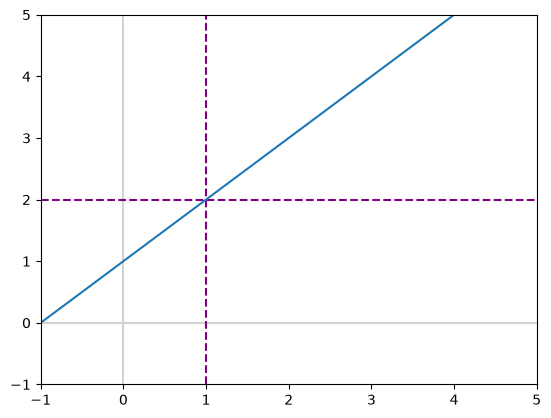

In [19]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.axvline(x=1, color='purple', linestyle='--')
plt.axhline(y=2, color='purple', linestyle='--')
_ = ax.plot(x,y)

**Volver a las slides aquí.**

$$\lim_{x \to 0} \frac{\text{sin } x}{x}$$

Otro caso de forma indeterminada $\frac{0}{0}$ en $x=0$ ($\sin(0)=0$), pero esta vez no se puede resolver factorizando — es uno de los límites más famosos de todo el cálculo, porque se usa para **derivar la función seno** (lo verás en el Segmento 2). Comprobemos numéricamente hacia qué valor se acerca:

In [20]:
def sin_fxn(my_x):
    my_y = np.sin(my_x)/my_x
    return my_y

In [ ]:
# Descomentar la siguiente línea produce un error de 'división por cero':
# y = sin_fxn(0)

In [22]:
sin_fxn(0.1)

np.float64(0.9983341664682815)

Por ambos lados de $x=0$, el valor se acerca a **1**: $\lim_{x \to 0} \frac{\sin x}{x} = 1$.

In [23]:
sin_fxn(0.001)

np.float64(0.9999998333333416)

In [24]:
sin_fxn(-0.1)

np.float64(0.9983341664682815)

In [25]:
sin_fxn(-0.001)

np.float64(0.9999998333333416)

In [26]:
y = sin_fxn(x)

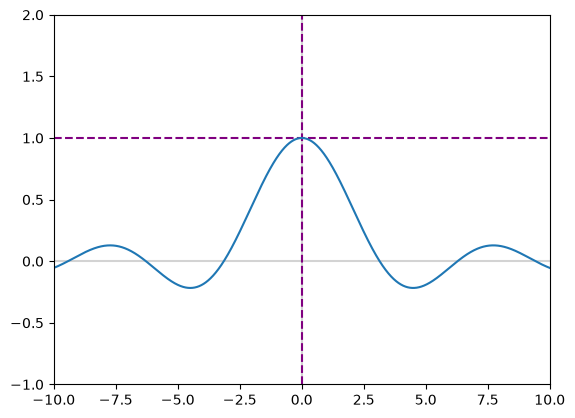

In [27]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-10, 10)
plt.ylim(-1, 2)
plt.axvline(x=0, color='purple', linestyle='--')
plt.axhline(y=1, color='purple', linestyle='--')
_ = ax.plot(x,y)

**Volver a las slides aquí.**

$$ \lim_{x \to \infty} \frac{25}{x} $$

Aquí $x$ no se acerca a un número, sino que **crece sin límite** ($x \to \infty$). La pregunta es la misma: ¿a qué valor se acerca $f(x)$? Vamos a probar con números cada vez más grandes:

In [28]:
def inf_fxn(my_x):
    my_y = 25/my_x
    return my_y

In [30]:
inf_fxn(1e3)

0.025

Cuanto mayor es $x$, más pequeño (más cerca de 0) es $\frac{25}{x}$. Así que $\lim_{x \to \infty} \frac{25}{x} = 0$ — la función tiene una **asíntota horizontal** en $y=0$.

In [31]:
inf_fxn(1e6)

2.5e-05

In [32]:
y = inf_fxn(x)

Esta vez representamos la función en un rango amplio de $x$, **incluyendo el paso por $x=0$** — donde, a diferencia del límite en el infinito que acabamos de calcular, la función ni siquiera está definida (división entre 0). Fíjate en la gráfica: al dibujar todos los puntos de golpe, Matplotlib conecta el punto justo a la izquierda de 0 (muy negativo) con el de justo a la derecha (muy positivo) mediante una línea recta vertical — un **artefacto visual**, no el comportamiento real de la función. Vamos a arreglarlo:

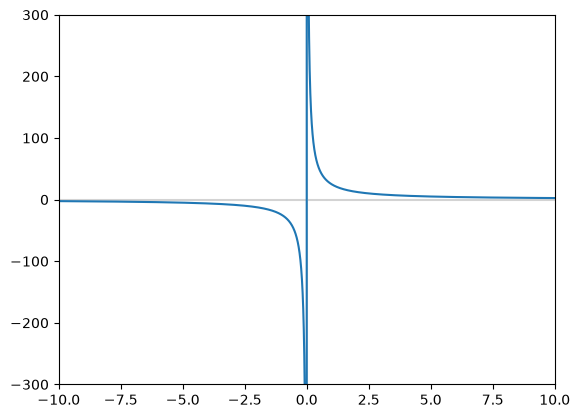

In [33]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-10, 10)
plt.ylim(-300, 300)
_ = ax.plot(x, y)

In [34]:
left_x = x[x<0]
right_x = x[x>0]

Separamos los valores de $x$ en dos mitades (antes y después del punto conflictivo $x=0$) para tratarlas como dos curvas independientes:

In [35]:
left_y = inf_fxn(left_x)
right_y = inf_fxn(right_x)

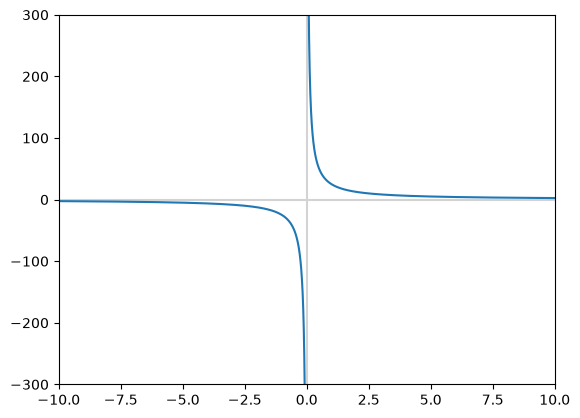

In [36]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-10, 10)
plt.ylim(-300, 300)
ax.plot(left_x, left_y, c='C0')
_ = ax.plot(right_x, right_y, c='C0')

Ahora sí se ve el comportamiento real: al acercarnos a $x=0$ por la izquierda, $f(x)$ se dispara hacia $-\infty$; por la derecha, hacia $+\infty$. Como los dos lados **no** se acercan al mismo valor (ni siquiera al mismo tipo de infinito), decimos que $\lim_{x \to 0} \frac{25}{x}$ **no existe** — a diferencia del límite en el infinito de antes, que sí existía y valía 0. Guarda esta idea para el Ejercicio 5.

**Ejercicios:**

Evalúa los límites siguientes utilizando las técnicas de las diapositivas o las anteriores.

1. $$ \lim_{x \to 0} \frac{x^2-1}{x-1} $$
2. $$ \lim_{x \to -5} \frac{x^2-25}{x+5} $$
3. $$ \lim_{x \to 4} \frac{x^2 -2x -8}{x-4} $$
4. $$ \lim_{x \to -\infty} \frac{25}{x} $$
5. $$ \lim_{x \to 0} \frac{25}{x} $$

Para tu información: Aunque no es necesario para ML ni para este currículo de *Fundamentos de ML*, la librería de matemáticas simbólicas [SymPy](https://www.sympy.org/en/index.html) incluye un método `limits()`. Puedes leer sobre su aplicación para evaluar límites de expresiones [aquí](https://www.geeksforgeeks.org/python-sympy-limit-method/).

**Volver a las slides aquí.**

1. $$ \lim_{x \to 0} \frac{x^2-1}{x-1} $$


In [39]:
import sympy as sp

x = sp.symbols('x')
f = (x**2-1)/(x-1)

sp.limit(f, x, 0, '+')



1

In [40]:
sp.limit(f, x, 0, '-')

1

2. $$ \lim_{x \to -5} \frac{x^2-25}{x+5} $$

In [54]:
x = sp.symbols('x')
f = (x**2-25)/(x+5)

sp.limit(f, x, -5, '+')

-10

In [55]:
sp.limit(f, x, -5, '-')

-10

3. $$ \lim_{x \to 4} \frac{x^2 -2x -8}{x-4} $$

In [43]:
x = sp.symbols('x')
f = (x**2-2*x-8)/(x-4)

sp.limit(f, x, 4, '+')

6

In [ ]:



sp.limit(f, x, 4, '-')

6

4. $$ \lim_{x \to -\infty} \frac{25}{x} $$

In [46]:
x = sp.symbols('x')
f = (25)/(x)

sp.limit(f, x,  sp.oo)

0

In [ ]:


sp.limit(f, x,  -sp.oo)

0

5. $$ \lim_{x \to 0} \frac{25}{x} $$

In [48]:
x = sp.symbols('x')
f = (25)/(x)

sp.limit(f, x,  0, '+')

oo

In [56]:
sp.limit(f, x,  0, '-')

-5

## Segmento 2: Cálculo de Derivadas con Diferenciación

En el Segmento 1 aprendimos a preguntar «¿a qué valor se acerca esta función?». Ahora vamos a usar esa misma idea para responder una pregunta distinta y mucho más útil: **¿de qué manera y con qué rapidez cambia una función en un punto exacto?** A esa respuesta se le llama **derivada**.

No hace falta ser un experto en matemáticas para seguir este segmento: la idea central es sencilla — vamos a calcular una **pendiente** (cuánto sube o baja una recta) cada vez con más precisión, hasta llegar al valor exacto en un solo punto. Todo lo que sigue es la versión «paso a paso, a mano» de algo que en ciencia de datos casi nunca se calcula manualmente, pero que hay que entender una vez para poder confiar en la caja negra: **la derivada es, literalmente, la pieza matemática que le dice a un modelo de Machine Learning en qué dirección y cuánto ajustar sus parámetros para cometer menos error** (el descenso de gradiente del que seguro has oído hablar).

Traigamos de vuelta a nuestro viejo amigo $y = x^2 + 2x + 2$:

Antes de nada, aclaremos dos palabras que vamos a usar mucho:

* **Pendiente**: cuánto sube o baja una recta. Piénsalo como una carretera: una pendiente grande es una cuesta empinada; una pendiente de 0 es completamente llana; una pendiente negativa es una bajada.
* **Derivada**: la pendiente de una **curva** (no de una recta), pero medida en un **único punto exacto** — como la velocidad que marca el velocímetro de un coche en un instante concreto, en vez de la velocidad media de todo el trayecto.

El reto es que una curva no tiene «una» pendiente fija (a diferencia de una recta) — la pendiente cambia en cada punto. El resto de este segmento resuelve, paso a paso, cómo calcular esa pendiente exacta en un punto concreto.

In [2]:
def f(my_x):
    my_y = my_x**2 + 2*my_x + 2
    return my_y

In [5]:
y = f(x)

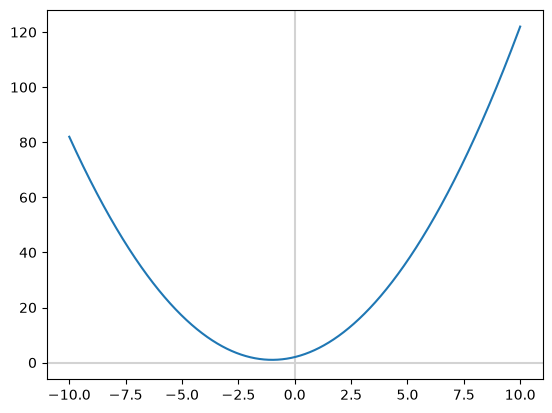

In [6]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
_ = ax.plot(x,y)

Identifiquemos la pendiente por ejemplo en $x = 2$.

Primero determinemos el valor de y $y$:

In [7]:
f(2)

10

Guay. Llamemos a este punto $P$, que se encuentra en (2, 10):

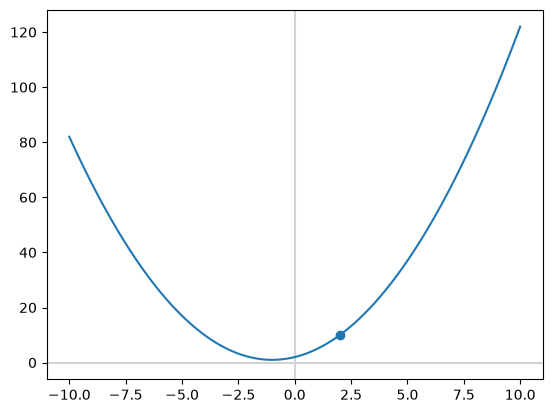

In [8]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10) # new
_ = ax.plot(x,y)

El *método delta* utiliza la diferencia entre dos puntos para calcular la pendiente. Para ilustrarlo, definamos otro punto, $Q$ donde, digamos, $x = 5$.

¿Por qué necesitamos un segundo punto? Porque la pendiente, por definición, compara **cómo cambia $y$ cuando cambia $x$** — y para comparar un cambio hacen falta, como mínimo, dos posiciones: un «antes» ($P$) y un «después» ($Q$). Con un único punto no hay nada que comparar todavía.

In [10]:
f(5)

37

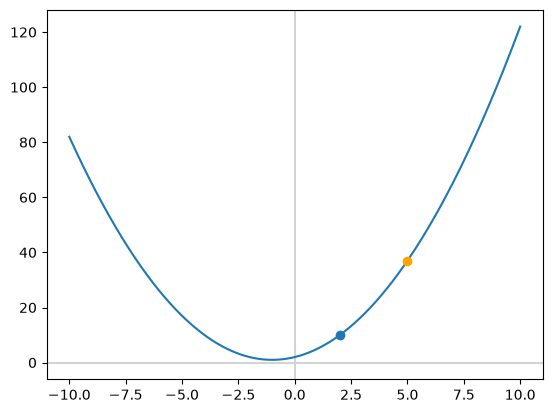

In [11]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(5, 37, c = 'orange', zorder=3) # new
_ = ax.plot(x,y)

Hallar la pendiente $m$ entre los puntos $P$ y $Q$:$$m = \frac{\text{cambio en }y}{\text{cambio en }x} = \frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1} = \frac{37-10}{5-2} = \frac{27}{3} = 9$$

Este $m=9$ es la pendiente de la recta que une $P$ y $Q$ — pero $Q$ está bastante lejos de $P$ ($x=5$ frente a $x=2$), así que esta recta se parece poco a la curva real cerca de $P$. Es solo una primera estimación, bastante burda, de la pendiente que buscamos.

In [12]:
m = (37-10)/(5-2)
m

9.0

Para representar la recta que pasa por $P$ y $Q$, podemos reordenar la ecuación de la recta $y = mx + b$ para resolver $b$:
$$b = y - mx$$

In [13]:
b = 37-m*5
b

-8.0

In [14]:
line_y = m*x + b

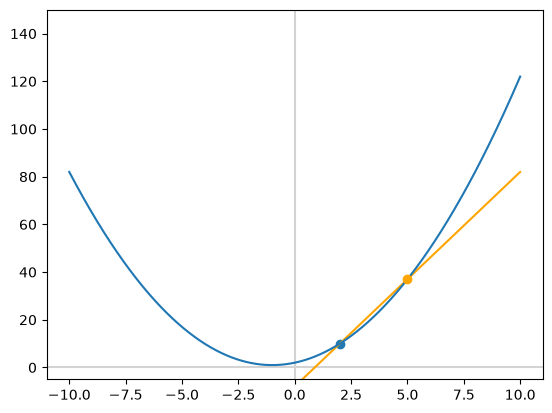

In [15]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(5, 37, c='orange', zorder=3)
plt.ylim(-5, 150) # new
plt.plot(x, line_y, c='orange') # new
_ = ax.plot(x,y)

Cuanto más se acerque $Q$ a $P$, más se acercará la pendiente $m$ a ser la verdadera tangente del punto $P$. Vamos a demostrarlo con otro punto $Q$ en $x = 2,1$.

Antes, nuestra $\Delta x$ entre $Q$ y $P$ era igual a 3. Ahora es mucho menor: $$\Delta x = x_2 - x_1 = 2,1 - 2 = 0,1 $$

In [16]:
f(2.1)

10.61

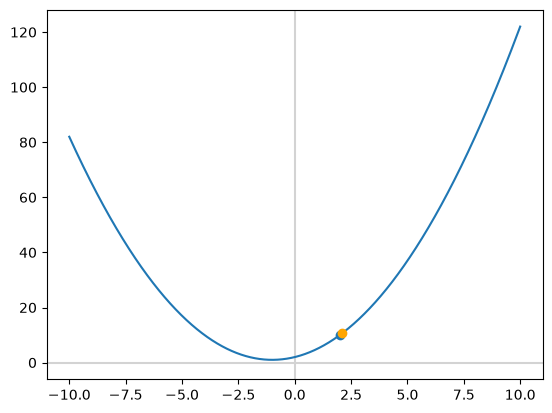

In [17]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(2.1, 10.61, c = 'orange', zorder=3)
_ = ax.plot(x,y)

In [18]:
m = (10.61-10)/(2.1-2)
m

6.099999999999989

In [19]:
b = 10.61-m*2.1
b

-2.199999999999978

In [20]:
line_y = m*x + b

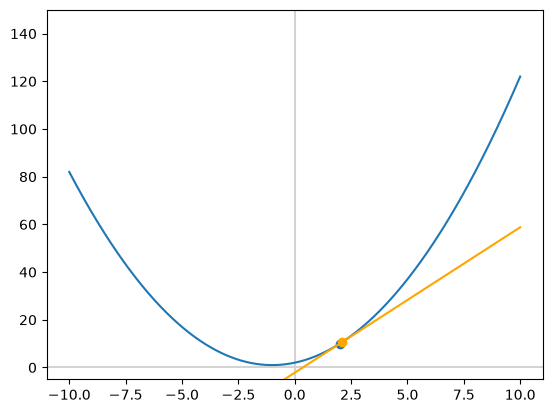

In [21]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(2.1, 10.61, c='orange', zorder=3)
plt.ylim(-5, 150)
plt.plot(x, line_y, c='orange', zorder=3)
_ = ax.plot(x,y)

Cuanto más se acerca $Q$ a $P$ (es decir, $\Delta x$ se aproxima a 0), más claro resulta que la pendiente $m$ en el punto $P$ = (2, 10) es igual a 6.

Fíjate en el patrón: con $Q$ en $x=5$ obtuvimos $m=9$; acercando $Q$ a $x=2{,}1$ obtuvimos un valor distinto (más cercano al real). Cuanto más *pegado* está $Q$ a $P$, menos «se nota» la curvatura de la parábola entre ambos puntos, y más se parece esa recta secante a la verdadera recta tangente en $P$ — la misma lógica del zoom infinito que vimos en el Segmento 1.

Hagamos $\Delta x$ extremadamente pequeño, 0,000001, para ilustrar esto:

In [22]:
delta_x = 0.000001
delta_x

1e-06

In [23]:
x1 = 2
y1 = 10

Reordenando $\Delta x = x_2 - x_1$, podemos calcular $x_2$ para nuestro punto $Q$, que ahora está extremadamente cerca de $P$:
$$x_2 = x_1 + \Delta x$$

In [24]:
x2 = x1 + delta_x
x2

2.000001

$y_2$ para nuestro punto $Q$ se puede obtener con la función habitual $f(x)$:
$$y_2 = f(x_2)$$

In [25]:
y2 = f(x2)
y2

10.000006000001001

Para hallar la pendiente $m$, seguimos usando $$m = \frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1}$$

In [26]:
m = (y2 - y1)/(x2 - x1)
m

6.000001000088901

¡Boom! Utilizando el método delta, hemos demostrado que en el punto $P$, la pendiente de la curva es 6.

Fíjate en lo que acabamos de hacer sin usar ninguna fórmula de derivadas: solo **evaluar la función dos veces muy cerca una de otra y dividir la diferencia**. Esto se llama **diferenciación numérica**, y es exactamente la idea (aunque implementada de forma mucho más eficiente y precisa) que usan las librerías de Machine Learning que no calculan derivadas «a mano» con álgebra — es la intuición que hay detrás de la **diferenciación automática** que veremos en el Segmento 3, y en última instancia, de cómo una red neuronal averigua qué peso subir o bajar durante el entrenamiento.

**Ejercicio**: Utilizando el método delta, halla la pendiente de la tangente donde $x = -1$.

In [44]:
f(-1)

1

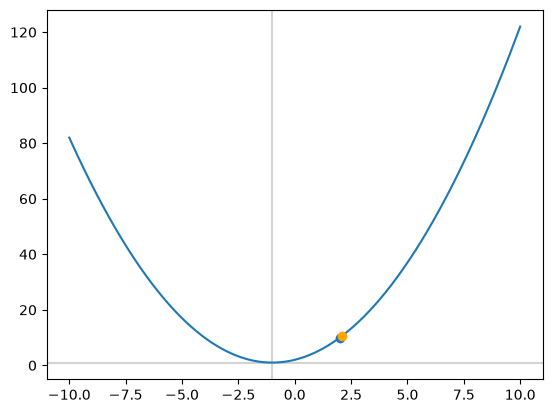

In [45]:
fig, ax = plt.subplots()
plt.axvline(x=-1, color='lightgray')
plt.axhline(y=1, color='lightgray')
plt.scatter(2, 10)
plt.scatter(2.1, 10.61, c = 'orange', zorder=3)
_ = ax.plot(x,y)

In [46]:
m = (10-1)/(2-(-1))
m

3.0

In [47]:
b = 1-m*(-1)
b

4.0

In [48]:
line_y = m*x + b

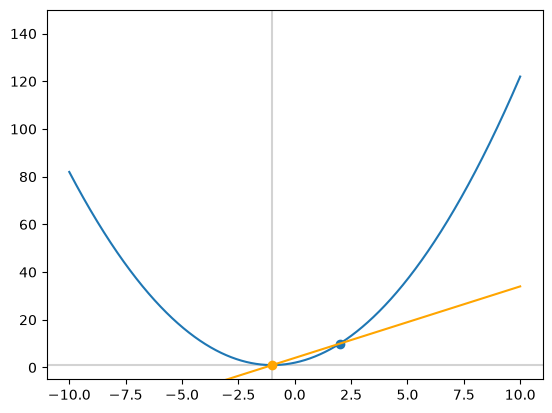

In [49]:
fig, ax = plt.subplots()
plt.axvline(x=-1, color='lightgray')
plt.axhline(y=1, color='lightgray')
plt.scatter(2, 10)
plt.scatter(-1, 1, c='orange', zorder=3)
plt.ylim(-5, 150)
plt.plot(x, line_y, c='orange', zorder=3)
_ = ax.plot(x,y)

**Alerta de spoiler. La solución está abajo.**

In [ ]:
x1 = -1

In [ ]:
y1 = f(x1)
y1

1

El punto $P$ está situado en (-1, 1)

In [50]:
delta_x

1e-06

In [51]:
x2 = x1 + delta_x
x2

2.000001

In [52]:
y2 = f(x2)
y2

10.000006000001001

Un pequeño inciso: Pertinente a la definición de la diferenciación como una ecuación, una forma alternativa de calcular $y_2$ es $f(x + \Delta x)$

In [53]:
y2 = f(x1 + delta_x)
y2

10.000006000001001

El punto $Q$ está en (-0,999999, 1,000000000001), extremadamente cerca de $P$.

In [54]:
m = (y2-y1)/(x2-x1)
m

6.000001000088901

Por tanto, como $x_2$ se acerca infinitamente a $x_1$, queda claro que la pendiente $m$ en $x_1 = -1$ es igual a cero. Vamos a trazarlo:

In [55]:
b = y2-m*x2
b

-2.000002000177801

In [56]:
line_y = m*x + b

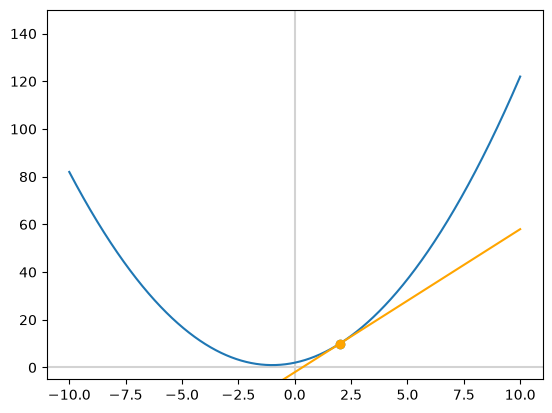

In [57]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(x1, y1)
plt.scatter(x2, y2, c='orange', zorder=3)
plt.ylim(-5, 150)
plt.plot(x, line_y, c='orange', zorder=3)
_ = ax.plot(x,y)

Como $Q$ se hace infinitamente cerca de $P$:
* $x_2$ - $x_1$ se aproxima a 0
* En otras palabras, $\Delta x$ se aproxima a 0.
* Esto se puede denotar como $\Delta x \to 0$

Utilizando el método delta, hemos obtenido la definición de diferenciación a partir de los primeros principios. La derivada de $y$ (denotado $dy$) con respecto a $x$ (denotado $dx$) se puede representar como:
$$\frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{\Delta y}{\Delta x}$$

Expandiendo $\Delta y$ a $y_2 - y_1$:
$$\frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{y_2 - y_1}{\Delta x}$$

Finalmente, sustituyendo $y_1$ por $f(x)$ y sustituyendo $y_2$ por $f(x + \Delta x)$, obtenemos una representación común de la diferenciación:
$$\frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

Esta es, probablemente, **la fórmula más importante de todo el cálculo aplicado a Machine Learning**. Tradúcela así para ciencia de datos: si $f(x)$ es el **error** que comete un modelo y $x$ es uno de sus **parámetros** (un peso), entonces $\frac{dy}{dx}$ te dice **en qué dirección se movería el error si tocases ese parámetro un pelín** — y por tanto, hacia dónde hay que mover el parámetro para reducir el error. Ese es, ni más ni menos, el mecanismo detrás del **descenso de gradiente**: repetir «calcula la derivada, da un pasito en la dirección que reduce el error» miles de veces hasta que el modelo aprende.

Observemos la ecuación de diferenciación en acción:

La función `diff_demo` de abajo no es más que la fórmula de la derivada de la celda anterior, traducida directamente a código: recibe una función `my_f`, un punto `my_x` y un salto pequeño `my_delta`, y calcula exactamente $\frac{f(x+\Delta x)-f(x)}{\Delta x}$. Con ella podemos probar automáticamente qué pasa al ir reduciendo $\Delta x$, en vez de repetir a mano cada cálculo como hicimos arriba.

In [58]:
def diff_demo(my_f, my_x, my_delta):
    return (my_f(my_x + my_delta) - my_f(my_x)) / my_delta

In [59]:
deltas = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001]

In [60]:
for delta in deltas:
    print(diff_demo(f, 2, delta))

7.0
6.099999999999994
6.009999999999849
6.000999999999479
6.000100000012054
6.000009999951316
6.000001000927568


In [61]:
for delta in deltas:
    print(diff_demo(f, -1, delta))

1.0
0.10000000000000009
0.009999999999998899
0.001000000000139778
9.99999993922529e-05
1.000000082740371e-05
1.000088900582341e-06


**Vuelve a las diapositivas aquí.**

### Las reglas de derivación (de un vistazo)

El método delta que acabas de ver funciona siempre, pero sería tremendamente lento de aplicar a mano cada vez. Por eso existen unas cuantas **reglas** que permiten derivar funciones complejas combinando derivadas ya conocidas, sin volver a pasar por el límite cada vez. No las desarrollamos con código aquí (son puramente algebraicas, y las tienes en las diapositivas/vídeo de esta sección), pero merece la pena tenerlas todas delante de un vistazo:

| Regla | Fórmula | En una frase |
|---|---|---|
| Constante | $\dfrac{d}{dx}[c] = 0$ | Una constante nunca cambia, así que su pendiente es 0. |
| Potencia | $\dfrac{d}{dx}[x^n] = nx^{n-1}$ | Baja el exponente como multiplicador y le resta 1. |
| Múltiplo constante | $\dfrac{d}{dx}[c\cdot f(x)] = c\cdot f'(x)$ | Una constante que multiplica «sale fuera» de la derivada. |
| Suma | $\dfrac{d}{dx}[f(x)+g(x)] = f'(x)+g'(x)$ | La derivada de una suma es la suma de las derivadas. |
| Producto | $\dfrac{d}{dx}[f(x)g(x)] = f'(x)g(x)+f(x)g'(x)$ | Deriva uno, deja el otro; y viceversa; suma ambos. |
| Cociente | $\dfrac{d}{dx}\!\left[\dfrac{f(x)}{g(x)}\right] = \dfrac{f'(x)g(x)-f(x)g'(x)}{g(x)^2}$ | Como el producto, pero restando y dividiendo entre $g(x)^2$. |
| **Cadena** | $\dfrac{d}{dx}\big[f(g(x))\big] = f'(g(x))\cdot g'(x)$ | Deriva «de fuera hacia dentro», multiplicando cada capa. |

**La regla de la cadena es, con diferencia, la más importante para Machine Learning** — y merece una mención aparte. Una red neuronal es, matemáticamente, una **composición de funciones** (la salida de una capa alimenta a la siguiente): $\text{error} = L(f_3(f_2(f_1(x))))$. Para saber cómo afecta un peso de la *primera* capa al error *final*, hay que encadenar derivadas — exactamente la regla de la cadena, aplicada una y otra vez, capa por capa. Eso es literalmente lo que hace la **retropropagación (backpropagation)**: propagar la derivada del error hacia atrás a través de toda la red.

(De hecho, un problema clásico de entrenamiento, el *vanishing gradient* o «desvanecimiento del gradiente», viene directamente de aquí: la regla de la cadena implica *multiplicar* muchas derivadas seguidas, y si cada una es un número menor que 1, el producto se hace minúsculo a medida que la red es más profunda — el gradiente que le llega a las primeras capas acaba siendo casi 0, y esas capas dejan de aprender.)

**Para nuestro ejemplo de siempre**, $f(x)=x^2+2x+2$: si definimos $h(x)=f(x)^3$ (una composición: elevar al cubo el resultado de $f$), la regla de la cadena dice $h'(x)=3f(x)^2\cdot f'(x)$. Comprobémoslo con SymPy:

In [1]:
import sympy as sp
sym_x = sp.symbols('x')
sym_f = sym_x**2 + 2*sym_x + 2
sym_h = sym_f**3          # h(x) = f(x)^3, una composición de funciones

sp.diff(sym_h, sym_x)     # derivada "de golpe"


(6*x + 6)*(x**2 + 2*x + 2)**2

**Un último dato importante**: en la práctica, no necesitas aplicar ninguna de estas reglas a mano. `sp.diff()` ya las conoce todas y las combina automáticamente (por eso el resultado de la celda de arriba coincide con aplicar la regla de la cadena a mano); y el *autograd* de PyTorch/TensorFlow que veremos ahora en el Segmento 3 hace exactamente lo mismo, pero sobre tensores y de forma automática durante el entrenamiento. Conocer las reglas no es para calcular derivadas tú mismo en el día a día — es para entender *qué* está calculando la librería por debajo, y por qué backpropagation funciona (y a veces falla, como con el *vanishing gradient*).

### Combinando la regla del producto con la de la cadena

En la práctica, casi nunca usarás una sola regla de derivación aislada — lo normal es que una función mezcle varias piezas, y haya que combinar reglas. Un caso muy típico: derivar un **producto** en el que uno de los factores es, a su vez, una **composición** de funciones (necesita la regla de la cadena). Vamos a verlo con un ejemplo, reutilizando nuestro $f(x)=x^2+2x+2$ de siempre.

Definimos $h(x) = x^2 \cdot f(x)^3$ — un producto de dos funciones: $u(x)=x^2$ y $v(x)=f(x)^3$ (esta última es la misma composición que vimos en el apartado anterior).

**Paso 1 — derivamos cada factor por separado:**

* $u(x)=x^2 \Rightarrow u'(x)=2x$ (regla de la potencia).
* $v(x)=f(x)^3 \Rightarrow v'(x)=3f(x)^2\cdot f'(x)$ (regla de la cadena, ya vista arriba).

**Paso 2 — aplicamos la regla del producto**, $\, h'(x)=u'(x)v(x)+u(x)v'(x)$, sustituyendo lo que acabamos de calcular:

$$ h'(x) = 2x \cdot f(x)^3 \;+\; x^2 \cdot 3f(x)^2 f'(x) $$

Fíjate en la estructura: **cada** derivada dentro de la fórmula del producto puede, a su vez, necesitar su propia regla — aquí la cadena aparece «anidada» dentro del producto.

Comprobémoslo con SymPy, comparando nuestro resultado «a mano» con `sp.diff()`:

In [1]:
u = sym_x**2
v = sym_f**3
h = u * v

dh_mano = 2*sym_x*sym_f**3 + sym_x**2 * 3*sym_f**2*sp.diff(sym_f, sym_x)
dh_sympy = sp.diff(h, sym_x)

sp.simplify(dh_mano - dh_sympy)   # si coinciden, esto da 0


0

Y evaluamos la derivada en un punto concreto, por ejemplo $x=1$, para tener un número final con el que comparar:

In [2]:
dh_sympy.subs(sym_x, 1)


550

El `0` confirma que las dos formas de calcularla coinciden, y $h'(1)=550$. **La lección para ciencia de datos**: las funciones de coste reales casi nunca son «una sola pieza» — mezclan sumas, productos y composiciones (por ejemplo, un término de regularización que *multiplica* un peso por una función del error, o una función de activación *compuesta* dentro de otra capa). El autograd de PyTorch/TensorFlow (Segmento 3) resuelve automáticamente combinaciones así de complejas — pero ahora ya sabes que, por debajo, no está haciendo magia: solo está aplicando estas mismas reglas (producto, cadena, suma...) una y otra vez, en el orden correcto.

## Segmento 3: Diferenciación Automatica

Este es el segmento donde todo lo anterior da sus frutos. En el Segmento 2 calculamos derivadas «a mano»: probando $\Delta x$ cada vez más pequeños (método delta), y luego vimos las reglas algebraicas que permiten derivar sin ese proceso. Aquí vamos a ver la **tercera forma** de obtener una derivada — la que de verdad se usa dentro de cualquier framework de Machine Learning — y en la que ni siquiera hace falta escribir la fórmula de la derivada: la librería la calcula por ti.

**TensorFlow** y **PyTorch** son las dos bibliotecas de diferenciación automática más populares.

Es fácil confundir la **diferenciación automática** (*autodiff*) con las otras dos formas de derivar que ya conoces, así que aclarémoslo antes de nada:

* **Numérica** (Segmento 2, `diff_demo`): aproxima la derivada probando un $\Delta x$ pequeño. Es solo una estimación, con algo de error de redondeo.
* **Simbólica** (SymPy, `sp.diff`): manipula la fórmula algebraica y te devuelve otra fórmula exacta, como harías en papel.
* **Automática** (*autodiff*, esta sección): **no** aproxima ni manipula fórmulas. La librería va anotando, paso a paso, cada operación que haces sobre un tensor (sumar, elevar al cuadrado, multiplicar...) — a esto se le llama construir un **grafo computacional**. Cuando le pides la derivada, recorre ese grafo hacia atrás y aplica la **regla de la cadena automáticamente** en cada paso (¡la misma regla de la cadena del Segmento 2!). El resultado es tan exacto como el simbólico, pero funciona sobre *código* en vez de sobre fórmulas escritas a mano — por eso es la única de las tres opciones que escala a redes neuronales con millones de operaciones.

Vamos a usarlas para derivar $dy/dx$ en $x = 5$ donde:

$$y = x^2$$

$$ \frac{dy}{dx} = 2x = 2(5) = 10 $$

Usamos una función deliberadamente sencilla ($y=x^2$, la regla de la potencia del Segmento 2) para poder centrarnos en la **mecánica** del autodiff — los pasos que vas a ver a continuación funcionan exactamente igual aunque $y$ sea una red neuronal entera con millones de parámetros.

### Autodiff con PyTorch

La receta de PyTorch tiene siempre estos mismos pasos, en este orden:

1. Crear el tensor de entrada.
2. Decirle a PyTorch que **rastree** las operaciones sobre ese tensor (`requires_grad`).
3. Hacer el cálculo normal — esto se llama el ***forward pass*** ("paso hacia delante") — mientras PyTorch construye el grafo computacional por detrás, en silencio.
4. Pedir la derivada con `.backward()` — el ***backward pass*** — que recorre ese grafo en sentido inverso.
5. Leer el resultado en `.grad`.

In [1]:
import torch

In [2]:
x = torch.tensor(5.0)

Usamos `5.0` (float) y no `5` (int) a propósito: al igual que vimos con `torch.norm()` en el notebook de álgebra lineal, PyTorch necesita tensores de tipo decimal para poder calcular gradientes — con enteros daría error.

In [3]:
x

tensor(5.)

In [4]:
x.requires_grad_() # rastrear gradientes de forma contagiosa mediante el paso hacia delante

tensor(5., requires_grad=True)

Este es el paso clave: le decimos a PyTorch «a partir de ahora, apunta todo lo que le hagas a `x`, porque más adelante querré la derivada». (El guion bajo al final, `requires_grad_()`, es la convención de PyTorch para indicar que la operación modifica el tensor *in situ*, en vez de crear uno nuevo.) Sin este paso, `y.backward()` más abajo fallaría — no habría nada que derivar hacia atrás.

In [5]:
y = x**2

Este es el ***forward pass***: una operación normal y corriente ($x^2$), salvo que como `x` tiene `requires_grad=True`, PyTorch anota en silencio «`y` se obtuvo elevando `x` al cuadrado» en su grafo computacional interno.

In [6]:
y.backward() # usando autodiff

Y aquí ocurre la magia: `.backward()` recorre el grafo que se acaba de construir, de `y` hacia `x`, aplicando automáticamente la regla de la potencia (y, en un grafo más largo, encadenándola con la regla de la cadena) para calcular $\frac{dy}{dx}$ — sin que hayamos escrito la fórmula $2x$ en ningún sitio.

In [7]:
x.grad

tensor(10.)

`10.0` — coincide exactamente con el cálculo analítico de arriba ($2\times5=10$), pero PyTorch ha llegado ahí sin que le diéramos la fórmula $\frac{dy}{dx}=2x$: la ha deducido observando las operaciones que hicimos.

### Autodiff con TensorFlow

TensorFlow sigue la misma idea, con una diferencia de estilo: en vez de marcar el tensor una vez (`requires_grad_()`) y dejar que todo lo que pase después se rastree automáticamente, TensorFlow te pide que abras explícitamente un bloque «de grabación» — el `GradientTape` ("cinta de gradientes") — y le digas qué tensores debe vigilar dentro de ese bloque.

In [ ]:
import tensorflow as tf

In [ ]:
x = tf.Variable(5.0)

In [ ]:
with tf.GradientTape() as t:
    t.watch(x) # trackeamos el forward pass
    y = x**2

`t.watch(x)` es el equivalente de TensorFlow al `requires_grad_()` de PyTorch: «vigila las operaciones sobre `x` dentro de esta cinta». Todo lo que ocurre dentro del bloque `with` (aquí, `y = x**2`) queda grabado en la cinta `t`, lista para poder derivar hacia atrás en cuanto salgamos del bloque.

In [ ]:
t.gradient(y, x) # usamos autodiff

<tf.Tensor: shape=(), dtype=float32, numpy=10.0>

`t.gradient(y, x)` es el equivalente de TensorFlow a `.backward()` + `.grad`, en una sola llamada: rebobina la cinta y calcula $\frac{dy}{dx}$ — de nuevo, `10.0`, sin que hayamos escrito la fórmula en ningún sitio.

**Volver a las slides aquí.**

Como de costumbre, PyTorch se siente más intuitivo y pitónico que TensorFlow. Ver el cuaderno independiente [*Regresión en PyTorch*](https://github.com/joanby/matematicas-ml/blob/master/notebooks/regression-in-pytorch.ipynb) para un ejemplo de autodiff emparejado con descenso de gradiente para ajustar una línea de regresión simple.

**Y así es, literalmente, cómo se entrena cualquier modelo**: en cada iteración se repite el mismo ciclo que acabas de ver a mano — (1) *forward pass* (calcular la predicción y el error con los parámetros actuales), (2) `.backward()` (calcular automáticamente cómo cambia ese error respecto a cada parámetro), y (3) mover cada parámetro un poco en la dirección que reduce el error (eso ya es el trabajo del *optimizador*, fuera del alcance de este notebook — lo verás en *Álgebra Lineal II* y en el tema de *Optimización*). Cambia $y=x^2$ por la función de pérdida de una red con millones de parámetros, y el proceso —conceptualmente— es exactamente este.

### De la teoría a un modelo real: la regresión lineal como grafo

Cerremos el notebook uniendo todos los hilos: ¿cómo se ve, en la práctica, un modelo de Machine Learning como «grafo computacional»? Tomemos el ejemplo más simple posible, la regresión lineal que ya viste en el notebook de álgebra lineal: $\hat{y} = wx + b$, con un **error cuadrático** $L=(\hat{y}-y)^2$ frente al valor real $y$.

Como grafo (cada operación es un nodo, cada flecha es un tensor fluyendo hacia la siguiente operación):

```
x ──────┐
        ×  (w·x)
w ──────┘   │
            +──► ŷ
b ──────────┘    │
                  −  (ŷ − y)
y ────────────────┘   │
                       ^2 ──► L
```

$x$ e $y$ son los **datos** (fijos, no se aprenden); $w$ y $b$ son los **parámetros** del modelo — los que queremos ajustar. Fíjate en que esto es *exactamente* la misma estructura que el ejemplo de $y=x^2$ de más arriba, solo que con más operaciones encadenadas (multiplicar, sumar, restar, elevar al cuadrado) — y el autodiff no necesita saber nada especial sobre «regresión lineal»: solo sabe derivar cada una de esas operaciones básicas y encadenarlas con la regla de la cadena.

Vamos a construir este grafo con PyTorch, con $w=2$, $b=1$, un dato $x=3$ y su valor real $y=10$:

In [1]:
w = torch.tensor(2.0, requires_grad=True)   # parámetro 1 (pendiente)
b = torch.tensor(1.0, requires_grad=True)   # parámetro 2 (intersección)
x = torch.tensor(3.0)                       # dato de entrada (no se aprende)
y_true = torch.tensor(10.0)                 # valor real que queríamos predecir

y_pred = w * x + b        # forward pass: la predicción del modelo, ŷ = wx + b
loss = (y_pred - y_true)**2   # forward pass: el error cuadrático, L = (ŷ-y)²

loss.backward()           # backward pass: deriva L respecto a TODO lo que tenga requires_grad=True

print(f"Predicción: {y_pred.item()}")
print(f"Error (loss): {loss.item()}")
print(f"dL/dw = {w.grad.item()}")
print(f"dL/db = {b.grad.item()}")


Predicción: 7.0
Error (loss): 9.0
dL/dw = -18.0
dL/db = -6.0


Con $w=2,b=1$ el modelo predice $\hat{y}=2(3)+1=7$, bastante lejos del valor real $10$ — de ahí el error $(7-10)^2=9$. Una única llamada a `.backward()` nos da **ambos gradientes a la vez**, sin haber escrito ni una derivada:

* $\frac{\partial L}{\partial w}=-18$: como es negativo, **aumentar** $w$ reduciría el error.
* $\frac{\partial L}{\partial b}=-6$: igualmente, **aumentar** $b$ también ayudaría.

Esto es exactamente lo que hace el **descenso de gradiente**: coge estos dos números y mueve $w$ y $b$ un poquito en la dirección que los reduce (es decir, en sentido contrario al gradiente), repitiendo el ciclo forward→backward→ajustar miles de veces hasta que el error se hace pequeño. Con dos parámetros lo acabamos de hacer a mano en una celda; una red neuronal moderna repite exactamente esto mismo con millones de parámetros a la vez — el notebook [*Regresión en PyTorch*](https://github.com/joanby/matematicas-ml/blob/master/notebooks/regression-in-pytorch.ipynb) que se menciona más arriba hace precisamente eso, encadenando este ciclo para ajustar una recta a datos reales.

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial de los 3 segmentos, para repasar sin releer todo el notebook.

### Qué es el cálculo (y por qué importa en ciencia de datos)

* **Cálculo diferencial** (este notebook): mide tasas de cambio, mediante **derivadas**. **Cálculo integral**: mide acumulación/áreas (se ve en *Cálculo II*).
* Historia en una línea: método de agotamiento de **Arquímedes** (aproximar con polígonos) → formalizado por **Newton y Leibniz** (s. XVII).
* Por qué importa: entrenar un modelo = optimización (minimizar el error). La derivada (construida sobre límites) es lo que le dice al modelo en qué dirección ajustar sus parámetros — la base del descenso de gradiente y *backpropagation*.

### El concepto de límite

$$ \lim_{x \to a} f(x) = L $$

El valor al que se **acerca** $f(x)$ cuando $x$ se acerca a $a$ — una pregunta sobre *tendencia*, no sobre el valor exacto en ese punto. $f$ ni siquiera necesita estar definida en $x=a$ para que el límite exista.

### Formas indeterminadas y discontinuidades evitables

* Una función puede dar $\frac{0}{0}$ en un punto (no está definida ahí) y aun así tener límite — se dice que tiene una **discontinuidad evitable** («un agujero» en la gráfica).
* Ejemplos: $\lim_{x \to 1} \frac{x^2-1}{x-1}=2$ (se resuelve factorizando) y $\lim_{x \to 0} \frac{\sin x}{x}=1$ (un límite clásico, usado más adelante para derivar el seno).

### Límites en el infinito y límites que no existen

* $\lim_{x \to \infty} f(x)$: qué valor «estabiliza» la función cuando $x$ crece sin límite (asíntota horizontal). Ej: $\lim_{x \to \infty} \frac{25}{x}=0$.
* Si por la izquierda y por la derecha de un punto la función se acerca a valores distintos (o diverge de forma distinta), el límite **no existe** ahí. Ej: $\lim_{x \to 0} \frac{25}{x}$ no existe ($-\infty$ por la izquierda, $+\infty$ por la derecha).
* Truco práctico de `matplotlib`: al representar una función con una asíntota vertical, separa el dominio en dos mitades (antes/después del punto conflictivo) para evitar que dibuje una línea vertical falsa uniendo ambas ramas.

### El método delta: hallar una pendiente exacta

* **Pendiente** = cuánto sube/baja una recta (como una carretera). **Derivada** = la pendiente de una curva, pero en un único punto exacto (como la velocidad instantánea de un coche, no la media del trayecto).
* **Método delta**: para hallar la pendiente exacta en un punto $P$, se coge otro punto $Q$ cercano, se calcula $m=\frac{\Delta y}{\Delta x}$ entre ambos, y se repite acercando $Q$ cada vez más — el valor de $m$ se va estabilizando en un número: esa es la derivada.

### La fórmula de la derivada (y por qué importa en ciencia de datos)

$$ \frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{f(x+\Delta x) - f(x)}{\Delta x} $$

Formalmente: «la pendiente entre dos puntos, cuando la distancia entre ellos se hace cero». En ciencia de datos, si $f(x)$ es el **error** de un modelo y $x$ un **parámetro**, la derivada te dice **en qué dirección y cuánto** ajustar ese parámetro para reducir el error — es el mecanismo exacto detrás del **descenso de gradiente**. Calcularla probando $\Delta x$ pequeños (*diferenciación numérica*, lo que hace este notebook a mano) es la versión manual de lo que las librerías automatizan en el Segmento 3.

### Las reglas de derivación

* Constante ($\frac{d}{dx}[c]=0$), potencia ($\frac{d}{dx}[x^n]=nx^{n-1}$), múltiplo constante, suma, producto y cociente — combinan derivadas conocidas sin repetir el método delta cada vez. En la práctica, `sp.diff()` (o el autograd de PyTorch/TensorFlow) ya las aplica todas por ti.
* **La regla de la cadena** ($\frac{d}{dx}[f(g(x))]=f'(g(x))\cdot g'(x)$) es la más importante para ML: una red neuronal es una composición de funciones, y aplicar la cadena repetidamente capa a capa es exactamente la **retropropagación**. También explica el problema del *vanishing gradient* (multiplicar muchas derivadas pequeñas seguidas). En la práctica se combinan varias reglas a la vez (p. ej. producto + cadena, cuando uno de los factores de un producto es a su vez una composición) — las funciones de coste reales casi nunca son «una sola pieza».

### Diferenciación automática (autodiff)

* **Tres formas de derivar**: numérica (aproximar con $\Delta x$ pequeño), simbólica (SymPy, fórmula exacta) y **automática** (PyTorch/TensorFlow): la librería anota cada operación en un **grafo computacional** y, al pedir la derivada, lo recorre hacia atrás aplicando la regla de la cadena — sin fórmulas escritas a mano.
* Receta de PyTorch: crear tensor → `requires_grad_()` → operar (*forward pass*) → `.backward()` (*backward pass*) → leer `.grad`. En TensorFlow: `tf.Variable` → `tf.GradientTape()` + `t.watch(x)` → `t.gradient(y, x)`.
* Es exactamente el motor de cualquier entrenamiento de ML: forward pass (predicción + error) → backward pass (gradientes de todos los parámetros a la vez) → el optimizador mueve cada parámetro en la dirección que reduce el error. Una regresión lineal $\hat{y}=wx+b$ con error $L=(\hat{y}-y)^2$ es, en esencia, el mismo grafo que $y=x^2$, solo con más operaciones encadenadas.